# Day-Ahead Electricity Demand Forecasting (+24h Horizon)

This notebook extends a baseline short-term forecasting pipeline to a **day-ahead electricity demand forecasting problem**.

The objective is to evaluate how predictive performance changes when:
- the forecasting horizon is shifted from +1h to +24h
- exogenous weather variables (temperature) are introduced
- statistical and machine learning models are compared under realistic constraints

## Workflow

1. Load and preprocess electricity + weather data  
2. Align and validate time-series consistency  
3. Construct lag features with +24h target shift  
4. Add weather-based exogenous variables  
5. Train baseline, statistical, and ML models  
6. Evaluate them with a chronological train/test split  
7. Validate robustness with time-series cross-validation 

## Pipeline overview

Raw data → Time Alignment → Target Shift (+24h) → Feature Engineering → Train/Test Split → Model Training → Evaluation

## Models compared

### Baselines
- Naive forecast (t-24)

### Statistical models
- Exponential Smoothing (Holt-Winters)

### Machine learning models
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor

The goal is to move from a simplified forecasting setup to a more realistic **day-ahead electricity demand forecasting pipeline**, where predictive performance is evaluated under a +24h horizon and enriched with exogenous weather information.

Beyond accuracy, the focus is on model robustness, interpretability, and alignment with real-world energy forecasting constraints.

## Configuration

In [1]:
# =========================
# Project configuration
# =========================

DATA_PATH = "../data/PJME_hourly.csv"
TARGET_COL = "PJME_MW"

HORIZON = 24  # day-ahead forecasting

TEST_SIZE = 0.2
RANDOM_STATE = 42

# plotting window (first month)
PLOT_HOURS = 24 * 30

In [2]:
# ============================================================================
# Weather configuration: PJM East approximate center --> Philadelphia area
# ============================================================================

LAT = 39.95
LON = -75.16

## Imports

In [3]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit

from src.preprocessing import load_data, sort_by_time, run_data_checks
from src.weather import fetch_open_meteo_weather
from src.features import create_features
from src.train import (
    make_Xy,
    make_train_test_split,
    build_ridge_pipeline,
    build_random_forest_model,
    build_gradient_boosting_model,
    fit_predict,
)
from src.evaluate import rolling_forecast, evaluate_regression

## Data loading and preprocessing

I load the electricity demand dataset, standardize the timestamp format, convert it to datetime, and sort the series chronologically to ensure proper time-series structure for forecasting.

In [5]:
df = load_data("../data/PJME_hourly.csv")
df = sort_by_time(df)

print("Raw shape:", df.shape)
df.head()

Raw shape: (145366, 1)


,PJME_MW
timestamp,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


## Data quality checks

Before feature engineering, I run a set of basic validation checks to ensure the time series is reliable and suitable for forecasting. These checks include:

- ordering and continuity of timestamps  
- detection of duplicates and missing values  
- verification of expected hourly frequency  
- assessment of missing time steps in the full time range   

These steps are critical because forecasting models rely on consistent temporal spacing for lag and rolling features.

In [6]:
checks, time_deltas = run_data_checks(df)

print("Data checks")
for name, value in checks.items():
    print(f"- {name}: {value}")

print("\nMost common time deltas:")
print(time_deltas)

Data checks
- sorted_index: True
- duplicate_timestamps: 4
- missing_target_values: 0
- negative_target_values: 0
- missing_timestamps: 26

Most common time deltas:
timestamp
0 days 01:00:00    145331
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64


In [7]:
# Remove duplicated timestamps, if any, keeping the first occurrence
df = df[~df.index.duplicated(keep="first")].copy()

print("Shape after duplicate handling:", df.shape)

Shape after duplicate handling: (145362, 1)


## Target definition (+24h forecasting horizon)

To transform the problem into a supervised learning task, I shift the target variable by 24 hours ahead. This means that for each timestamp t, the model learns to predict the electricity demand at t + 24 hours.

This setup ensures a true **day-ahead forecasting scenario**, commonly used in energy markets and grid planning, and avoids data leakage, in the sense that all features must only contain information available at or before time t.

In [8]:
df = df.sort_index()

df["target"] = df[TARGET_COL].shift(-24)

print("Original shape:", df.shape)
print("Missing target values (expected at the end):", df["target"].isna().sum())

# Remove last 24 rows (no target available)
df = df.dropna(subset=["target"])

print("Shape after target alignment:", df.shape)

Original shape: (145362, 2)
Missing target values (expected at the end): 24
Shape after target alignment: (145338, 2)


The last 24 rows are removed because they do not have a valid target value after shifting.
This is expected and does not represent missing data issues.

## Horizon sensitivity analysis

While the primary focus of this project is day-ahead forecasting (+24h horizon), real-world energy forecasting systems must operate across multiple time horizons.

In practice, predictive difficulty and model performance can vary significantly depending on how far ahead the forecast is made. Short-term horizons (e.g. +1h) are typically dominated by strong autocorrelation, while longer horizons (e.g. +24h) require capturing more complex temporal patterns and external drivers.

To better understand this behavior, I extend the analysis to multiple forecasting horizons:

- +1 hour (very short-term)
- +3 hours (intra-day operational horizon)
- +6 hours (short-term planning)
- +24 hours (day-ahead baseline)

For each horizon, the target variable is shifted accordingly, while keeping the rest of the pipeline unchanged. This allows for a controlled comparison of model performance as a function of forecast horizon.

This analysis serves two main purposes:

- evaluate how predictive performance degrades with increasing horizon  
- assess the robustness of different models under varying operational constraints  

This step also addresses a key real-world consideration: forecasting systems must remain reliable even when immediate past information is not sufficient or available.

In [9]:
HORIZONS = [1, 3, 6, 24]  # hours ahead

df_horizons = {}
df = df.sort_index()

for h in HORIZONS:
    df_h = df.copy()
    
    # Shift target
    df_h["target"] = df_h[TARGET_COL].shift(-h)

    df_h = df_h.dropna(subset=["target"])   
    df_horizons[h] = df_h
    print(f"Horizon +{h}h -> shape: {df_h.shape}")

Horizon +1h -> shape: (145337, 2)
Horizon +3h -> shape: (145335, 2)
Horizon +6h -> shape: (145332, 2)
Horizon +24h -> shape: (145314, 2)


## Weather data integration (Open-Meteo API)

To improve the realism and predictive power of the model, external weather data is incorporated.

Electricity demand is strongly influenced by temperature, especially due to heating and cooling needs. Therefore, temperature is used as an exogenous variable.

I use the Open-Meteo API to retrieve historical hourly temperature data aligned with the PJM electricity demand timestamps.

### Why weather data matters

- Captures seasonal consumption effects
- Improves model performance during extreme temperatures
- Adds exogenous explanatory power beyond autocorrelation

## Weather-energy data alignment

Weather data is merged with electricity demand using timestamp alignment. This ensures:
- no leakage
- correct temporal matching
- consistent hourly frequency

In [10]:
start_date = df.index.min().date()
end_date = df.index.max().date()

weather_df = fetch_open_meteo_weather(
    latitude=LAT,
    longitude=LON,
    start_date=start_date,
    end_date=end_date,
    timezone="UTC"
)

df = df.reset_index().rename(columns={"index": "timestamp"})
df = df.merge(weather_df, on="timestamp", how="left")
df = df.set_index("timestamp")

print(df[["PJME_MW", "temperature"]].head())

                     PJME_MW  temperature
timestamp                                
2002-01-01 01:00:00  30393.0         -3.5
2002-01-01 02:00:00  29265.0         -3.7
2002-01-01 03:00:00  28357.0         -3.8
2002-01-01 04:00:00  27899.0         -4.1
2002-01-01 05:00:00  28057.0         -4.4


In [11]:
print("Missing temperature values:", df["temperature"].isna().sum())

print(df[["PJME_MW", "temperature"]].describe())

Missing temperature values: 0
             PJME_MW    temperature
count  145338.000000  145338.000000
mean    32079.281723      12.855045
std      6463.212290      10.288486
min     14544.000000     -21.900000
25%     27573.000000       4.600000
50%     31421.000000      13.400000
75%     35647.000000      21.400000
max     62009.000000      39.900000


## Feature engineering

To improve forecasting performance, a comprehensive set of engineered features is created to capture both internal demand dynamics and external drivers.

The feature set includes:

- **Temporal features**: hour of day, day of week, month, and weekend indicators  
- **Cyclical encoding**: sine/cosine transformations to properly represent periodic time structures  
- **Autoregressive components**: lagged electricity demand values to capture short- and long-term persistence  
- **Rolling statistics**: moving averages and variability measures to model local trends and volatility  
- **Weather-based features**: temperature and derived indicators to capture heating and cooling effects on demand  

All features are strictly computed using past information only, ensuring no data leakage and preserving the causal structure required in time-series forecasting.

Feature engineering is applied after target alignment (for each forecasting horizon), ensuring that each observation contains only information available up to time *t*, while the target corresponds to demand at time *t + h*.

This guarantees a realistic supervised learning setup consistent with real-world forecasting conditions.

### Lag constraint analysis (operational scenario)

In real-world energy forecasting, models are often subject to operational constraints that limit the availability of the most recent observations.

For example, due to data latency, processing time, or market gate closure requirements, the latest available demand value at prediction time may not correspond to the immediately preceding hour (*t-1*), but rather to an earlier time step (e.g. *t-3* or beyond).

To simulate this more realistic setting, I introduce a **lag constraint scenario**, where the model is restricted from using the most recent lag (`lag_1`) and instead relies on less recent information (e.g. `lag_3` and beyond).

This allows evaluating:

- how strongly model performance depends on immediate past observations  
- how robust different models are when recent information is unavailable  
- how forecasting accuracy degrades under operational delays  

This analysis reflects real-world constraints in energy systems, where forecasts must often be generated ahead of time under strict timing requirements.

In [12]:
# 1. Standard scenario (lag_1 available)
df_feat = create_features(df)

print("Feature matrix shape (lag_1):", df_feat.shape)

# 2. Constrained scenario (no lag_1)
df_feat_lag3 = create_features(df, use_lag1=False)

print("Feature matrix shape (lag_3 scenario):", df_feat_lag3.shape)

Feature matrix shape (lag_1): (145170, 22)
Feature matrix shape (lag_3 scenario): (145170, 21)


After feature construction, the resulting dataset is fully aligned for supervised learning. Each row contains only information available up to time *t*, while the target variable represents electricity demand at time *t + 24h*.

This ensures a realistic day-ahead forecasting framework and prevents information leakage from future observations.

## Train/test split

Given the temporal structure of the dataset, a **chronological train/test split** is used instead of a random split. 

This approach ensures that the model is trained exclusively on past data and evaluated on future observations, mimicking a real-world forecasting scenario. This prevents information leakage and ensures that performance metrics reflect true out-of-sample predictive capability.

In particular:

- the training set contains earlier time periods
- the test set contains later, unseen observations
- no shuffling is applied

Such a setup is essential in energy forecasting applications, where models must generalize to unseen future conditions.

In [13]:
X, y = make_Xy(df_feat, target_col=TARGET_COL)
X_train, X_test, y_train, y_test = make_train_test_split(X, y, test_size=TEST_SIZE)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (116136, 21)
X_test : (29034, 21)
y_train: (116136,)
y_test : (29034,)


## Rolling forecast evaluation (operational realism)

While a single chronological train/test split provides a useful first estimate of model performance, it still represents a simplified evaluation setup.

In real-world energy forecasting systems, models are not trained once and evaluated statically. Instead, forecasts are generated continuously over time, using only the information available up to the prediction timestamp.

To better simulate this behavior, I implement an **expanding window rolling forecast evaluation strategy**.

At each step:

- the model is trained on all data available up to time *t*  
- a prediction is generated for the next *step* horizon (*t + h*, e.g. 24 or 48 hours)  
- the training set grows incrementally as new observations become available  

This approach mimics how forecasting systems operate in production environments, where models are periodically retrained as new data arrives.

### Why this matters

Compared to a static train/test split, rolling forecasting:

- provides a more realistic estimate of model performance  
- captures temporal variability in model accuracy  
- avoids optimistic bias due to fixed training windows  
- better reflects operational forecasting workflows  

This step directly addresses a key limitation of offline evaluation and bridges the gap between a modeling exercise and a real-world forecasting system.

In [ ]:
rf_model = build_random_forest_model(
    n_estimators=80,
    max_depth=12
)

X_full, y_full = make_Xy(df_feat, target_col=TARGET_COL)

initial_train_size = int(len(X_full) * (1 - TEST_SIZE))

y_true_rf, y_pred_rf = rolling_forecast(
    rf_model,
    X_full,
    y_full,
    initial_train_size=initial_train_size,
    step=48
)

results_rf = evaluate_regression(y_true_rf, y_pred_rf)

print("Rolling Forecast Performance (Random Forest - Sliding Window)")
for metric, value in results_rf.items():
    print(f"{metric}: {value:.2f}")

## Forecasting models

To evaluate different approaches to the forecasting problem, I considered three categories of models:

1. a naive baseline model
2. a statistical time-series model (Exponential Smoothing)
3. machine learning models (Ridge, Random Forest, Gradient Boosting)

This comparison allows assessing the trade-off between simplicity, interpretability, and predictive performance.

## 1. Baseline model

Before training machine learning models, a simple baseline is established to provide a reference level of performance.

In particular, I made use of a **naive day-ahead forecast**, where electricity demand at time *t + 24h* is predicted using the demand observed at time *t*. This baseline is commonly used in energy forecasting and represents a strong benchmark due to the high autocorrelation of electricity demand.

Comparing advanced models against this baseline helps assess whether the added complexity provides meaningful improvements.

In [13]:
test_results = {}
predictions = {}

y_pred_naive = X_test["lag_24"]

test_results["Naive"] = evaluate_regression(y_test, y_pred_naive)
predictions["Naive"] = y_pred_naive

print("Naive baseline performance:")
for key, value in test_results["Naive"].items():
    print(f"{key}: {value:.4f}")

Naive baseline performance:
rmse: 3009.1488
mae: 2183.9776
r2: 0.7847


## 2. Statistical model

In addition to the naive baseline, a statistical time-series model is used as a benchmark.

In particular, I applied a **Exponential Smoothing (Holt-Winters)** to capture level, trend, and seasonality components in the electricity demand. This type of model is widely used in energy forecasting due to its interpretability and ability to model structured temporal patterns. It also provides a strong reference point, especially for longer forecasting horizons.

Unlike machine learning models, this approach does not rely on exogenous variables, but instead models the internal structure of the time series directly.

In [14]:
ts = df["PJME_MW"].sort_index().asfreq("h").interpolate()

hw_train_size = int(len(ts) * (1 - TEST_SIZE))
hw_train, hw_test = ts.iloc[:hw_train_size], ts.iloc[hw_train_size:]

# Fit only on training data
hw_model = ExponentialSmoothing(
    hw_train,
    trend="add",
    seasonal="add",
    seasonal_periods=24
)

hw_fit = hw_model.fit()

# Forecast on test horizon
y_pred_hw = hw_fit.forecast(len(hw_test))

test_results["Exponential Smoothing"] = evaluate_regression(hw_test, y_pred_hw)
predictions["Exponential Smoothing"] = y_pred_hw

print("\nExponential Smoothing performance:")
for key, value in test_results["Exponential Smoothing"].items():
    print(f"{key}: {value:.4f}")


Exponential Smoothing performance:
rmse: 5943.4194
mae: 4418.4364
r2: 0.1593


Exponential Smoothing captures general trend and daily seasonality, but shows limited ability to model external drivers and nonlinear effects. As a result, its performance is moderate compared to machine learning approaches, which benefit from richer feature sets such as lag structures and weather variables.

## 3. Machine learning models

To complement the baseline and statistical approaches, several machine learning models are trained to capture complex patterns in electricity demand.

In particular, I considered the following models:

- **Ridge Regression**, a regularized linear model used as a robust baseline, implemented within a scikit-learn Pipeline  
- **Random Forest Regressor**, an ensemble method based on decision trees, capable of capturing nonlinear relationships  
- **Gradient Boosting Regressor**, a boosting-based ensemble model that incrementally improves prediction accuracy

This setup enables a direct comparison between a simple linear approach and more flexible nonlinear models.

All models are trained on the same feature set and evaluated on the test set, ensuring a consistent and fair comparison with the naive baseline and the statistical model.

The use of a dictionary of models keeps the workflow modular, scalable, and easy to extend with additional estimators.

In [15]:
ridge = build_ridge_pipeline()
rf = build_random_forest_model()
gb = build_gradient_boosting_model()

models = {
    "Ridge": ridge,
    "Random Forest": rf,
    "Gradient Boosting": gb,
}

for name, model in models.items():
    y_pred = fit_predict(model, X_train, y_train, X_test)
    test_results[name] = evaluate_regression(y_test, y_pred)
    predictions[name] = y_pred

    print(f"\n{name} performance:")
    for key, value in test_results[name].items():
        print(f"{key}: {value:.4f}")


Ridge performance:
rmse: 895.7412
mae: 700.2683
r2: 0.9809

Random Forest performance:
rmse: 400.1840
mae: 292.3179
r2: 0.9962

Gradient Boosting performance:
rmse: 568.2609
mae: 439.3563
r2: 0.9923


In [16]:
results_df = (
    pd.DataFrame(test_results)
    .T
    .sort_values("rmse")
    .round(2)
)

results_df

,rmse,mae,r2
Random Forest,400.18,292.32,1.00
Gradient Boosting,568.26,439.36,0.99
Ridge,895.74,700.27,0.98
Naive,3009.15,2183.98,0.78
Exponential Smoothing,5943.42,4418.44,0.16


## Test-set performance

The table above compares all models on the holdout test set using:

- **RMSE**: penalizes large errors more strongly  
- **MAE**: average absolute error  
- **R²**: proportion of explained variance  

The results show a clear hierarchy of performance across model classes.

Naive and statistical approaches provide useful baselines. The Naive model already achieves reasonable accuracy due to the strong autocorrelation in electricity demand, while Exponential Smoothing captures general trend and daily seasonality but shows limited ability to model external drivers and nonlinear effects.

Unlike machine learning models, this approach does not rely on exogenous variables, but instead models the internal structure of the time series directly. As a result, its performance is moderate compared to machine learning approaches, which benefit from richer feature sets such as lag structures and weather variables.

Linear models (Ridge Regression) already achieve strong performance, explaining most of the variance in the data. However, tree-based ensemble models further improve predictive accuracy by capturing nonlinear relationships and feature interactions.

Among all models, **Random Forest** achieves the best overall performance in terms of RMSE and R², followed closely by **Gradient Boosting**, which also provides strong predictive power but slightly higher error in this configuration.

**Final takeaway:** machine learning models significantly outperform both naive and statistical baselines, with tree-based ensembles providing the most accurate forecasts.

In [ ]:
best_model_name = results_df.index[0]
y_pred_best = predictions[best_model_name]
best_model_name

'Random Forest'

## Prediction plots

To better understand model performance, I visualize predictions over time. Rather than focusing only on aggregate metrics, these plots show how well the models capture the temporal dynamics of electricity demand. 

For readability, the analysis focuses on the first month of the test period.

Two visualizations are presented:

1. actual vs predicted demand for the best-performing model  
2. comparison between actual demand, the best model, and the naive baseline  

This allows for a clear assessment of both predictive accuracy and improvement over a simple benchmark.

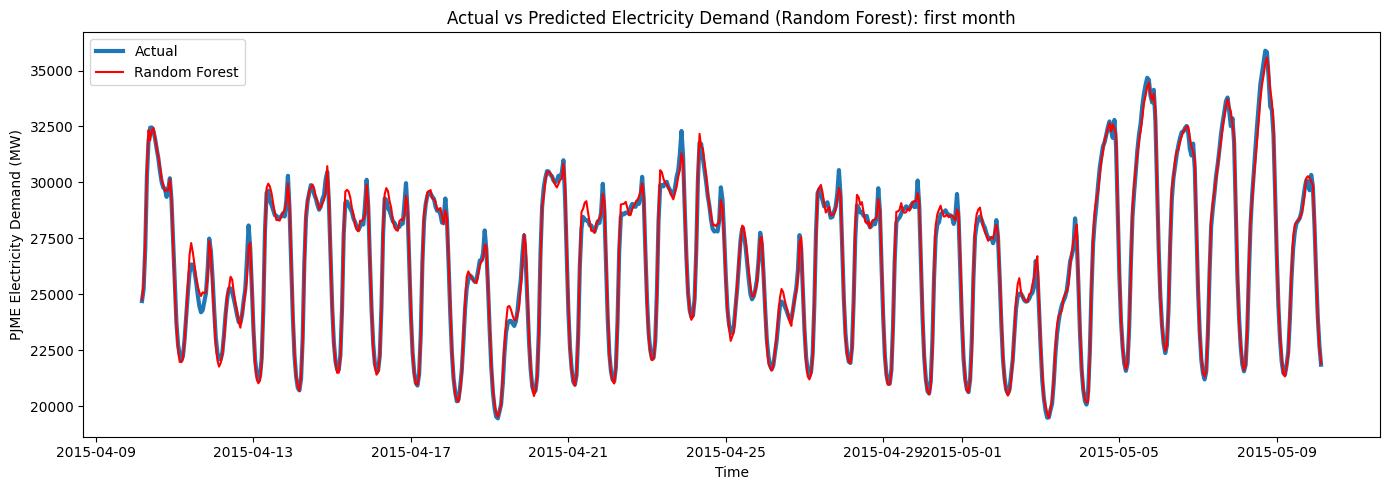

In [42]:
y_pred_naive = pd.Series(y_pred_naive, index=y_test.index)
y_pred_best = pd.Series(y_pred_best, index=y_test.index)

plt.figure(figsize=(14, 5))
plt.plot(
    y_test.iloc[:PLOT_HOURS].index,
    y_test.iloc[:PLOT_HOURS],
    label="Actual",
    linewidth=3
)
plt.plot(
    y_pred_best.iloc[:PLOT_HOURS].index,
    y_pred_best.iloc[:PLOT_HOURS],
    label=best_model_name,
    color="red"
)
plt.title("Actual vs Predicted Electricity Demand (Random Forest): first month")
plt.xlabel("Time")
plt.ylabel("PJME Electricity Demand (MW)")
plt.legend()
plt.tight_layout()
plt.savefig("../images/predictions_rf.png", dpi=300, bbox_inches="tight")
plt.show()

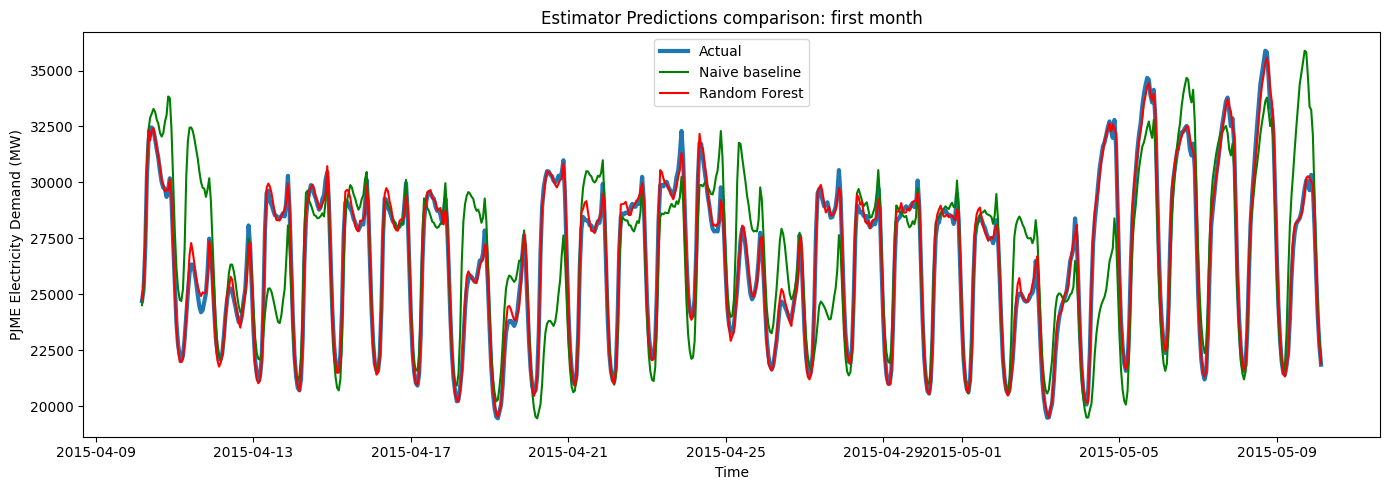

In [35]:
plt.figure(figsize=(14, 5))
plt.plot(
    y_test.iloc[:PLOT_HOURS].index,
    y_test.iloc[:PLOT_HOURS],
    label="Actual",
    linewidth=3
)
plt.plot(
    predictions["Naive"].iloc[:PLOT_HOURS].index,
    predictions["Naive"].iloc[:PLOT_HOURS],
    label="Naive baseline",
    color="green"
)
plt.plot(
    y_pred_best.iloc[:PLOT_HOURS].index,
    y_pred_best.iloc[:PLOT_HOURS],
    label=best_model_name,
    color="red"
)
plt.title("Estimator Predictions comparison: first month")
plt.xlabel("Time")
plt.ylabel("PJME Electricity Demand (MW)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
residuals = y_test - y_pred_best

plt.figure(figsize=(14,4))
plt.plot(residuals.iloc[:PLOT_HOURS], color="red")
plt.axhline(0)
plt.title("Residuals over time (Random Forest)")
plt.tight_layout()
plt.show()

## Stress Test and Extrapolation Analysis

To assess model robustness beyond standard test-set evaluation, a stress test is conducted on challenging operating conditions.

While standard metrics evaluate average performance, real-world forecasting systems must remain reliable under extreme and rare events, such as peak electricity demand or unusual weather conditions.

## Why stress testing matters

- Evaluates model robustness under distribution shifts  
- Tests performance during extreme demand periods  
- Identifies potential failure modes in real-world deployment  
- Complements standard train/test evaluation  

## Stress scenarios

The analysis focuses on three challenging regimes:

- Peak demand conditions (top 5% highest electricity consumption values)  
- Extreme temperature conditions (very hot or very cold weather)  
- Temporal shift analysis (performance stability over different time segments)  

This provides a deeper understanding of how the model behaves beyond average conditions.

In [ ]:
threshold = y_test.quantile(0.95)

peak_idx = y_test[y_test >= threshold].index

y_true_peak = y_test.loc[peak_idx]
y_pred_peak = pd.Series(y_pred_best, index=y_test.index).loc[peak_idx]

peak_results = evaluate_regression(y_true_peak, y_pred_peak)

print("Peak Demand Stress Test")
for k, v in peak_results.items():
    print(f"{k}: {v:.2f}")

In [ ]:
temp = X_test["temperature"]

temp_threshold_low = temp.quantile(0.05)
temp_threshold_high = temp.quantile(0.95)

extreme_idx = temp[(temp <= temp_threshold_low) | (temp >= temp_threshold_high)].index

y_true_ext = y_test.loc[extreme_idx]
y_pred_ext = pd.Series(y_pred_best, index=y_test.index).loc[extreme_idx]

extreme_results = evaluate_regression(y_true_ext, y_pred_ext)

print("Extreme Temperature Stress Test")
for k, v in extreme_results.items():
    print(f"{k}: {v:.2f}")

In [ ]:
split_point = int(len(y_test) * 0.5)

first_half_idx = y_test.index[:split_point]
second_half_idx = y_test.index[split_point:]

def eval_segment(idx, name):
    yt = y_test.loc[idx]
    yp = pd.Series(y_pred_best, index=y_test.index).loc[idx]
    res = evaluate_regression(yt, yp)
    print(f"\n{name}")
    for k, v in res.items():
        print(f"{k}: {v:.2f}")

eval_segment(first_half_idx, "First half test period")
eval_segment(second_half_idx, "Second half test period")

## Feature Importance

For interpretability, I analyze feature importance from the Random Forest model.

This helps answer a practical question: **which signals are most influential in predicting electricity demand?** In time series forecasting, lagged variables are typically the most important predictors because electricity demand exhibits strong temporal autocorrelation and daily/weekly repetition patterns.

In [36]:
random_forest_model = models["Random Forest"]

feature_importances = (
    pd.Series(random_forest_model.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

feature_importances.head(10)

lag_1                0.948412
hour_cos             0.025074
hour                 0.010168
hour_sin             0.004939
target               0.002038
temp_roll_mean_24    0.001697
rolling_std_24       0.001126
rolling_mean_24      0.000960
temp_lag_1           0.000761
temp_lag_24          0.000629
dtype: float64

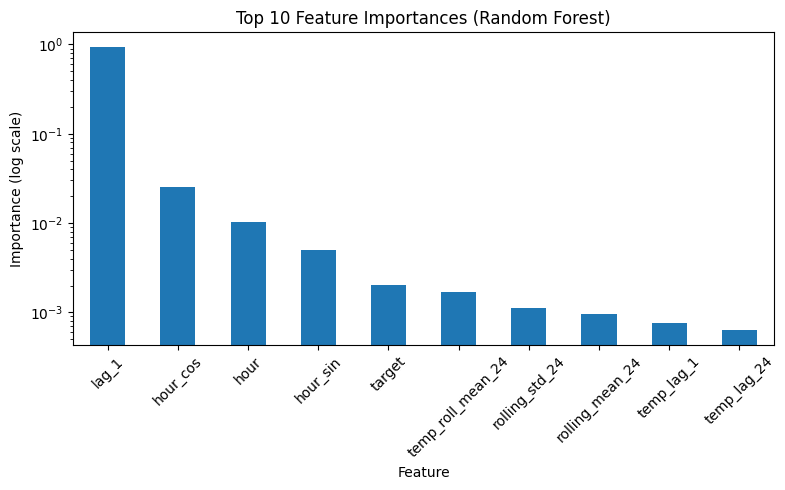

In [43]:
plt.figure(figsize=(8, 5))
feature_importances.head(10).plot(kind="bar")
plt.yscale("log")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Feature")
plt.ylabel("Importance (log scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/feature_importance_rf.png", dpi=300, bbox_inches="tight")
plt.show()

The feature importance analysis from the Random Forest model shows a highly consistent and interpretable pattern across both model versions.

The dominant feature is **`lag_1`**, which by a very large margin carries the highest predictive power. This confirms that electricity demand is extremely dependent on its most recent value, highlighting a **strong short-term autocorrelation** in the time series.

Among the remaining predictors, calendar-based features such as `hour`, `hour_sin`, and `hour_cos` provide the second most relevant source of information. These variables capture the strong **daily seasonality** present in electricity consumption, reflecting predictable intra-day usage patterns.

Rolling statistics (e.g. `rolling_mean_24`, `rolling_std_24`) contribute modestly to the model, suggesting that short-term aggregated behavior adds some value but is largely secondary compared to direct lagged signals.

In the extended feature set, weather-related variables such as `temp_roll_mean_24`, `temp_lag_1`, and `temp_lag_24` appear with low but non-zero importance. This indicates that temperature has a measurable influence on demand, although its effect is significantly weaker than intrinsic temporal dependencies. The presence of these features confirms that external drivers do improve the model, but only marginally in a short-term forecasting context.

Overall, the results reinforce a clear **hierarchy of predictive signals**: recent demand history is the primary driver, followed by daily seasonal structure, while weather and rolling statistics provide incremental improvements. This is consistent with typical behavior in short-term electricity load forecasting problems, where **autoregressive structure dominates predictive performance**.

## Time Series Cross-Validation

While a single train/test split provides a first estimate of model performance, it may be sensitive to the specific temporal partition of the data.

To obtain a more robust and reliable evaluation, I apply **TimeSeriesSplit cross-validation**, which preserves the chronological structure of the data and prevents any leakage from future observations into the training set.

Unlike standard cross-validation, this approach evaluates the models on sequentially expanding or shifting time windows, better reflecting a real-world forecasting scenario where predictions are always made on unseen future data.

In [38]:
tsscv = TimeSeriesSplit(n_splits=5)

cv_results = {name: [] for name in models}

for train_idx, val_idx in tsscv.split(X):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    for name, model in models.items():
        model_cv = clone(model)
        preds_cv = fit_predict(model_cv, X_train_cv, y_train_cv, X_val_cv)

        rmse_cv = evaluate_regression(y_val_cv, preds_cv)["rmse"]
        cv_results[name].append(rmse_cv)

cv_rmse_df = pd.DataFrame(cv_results, index=[f"Fold {i}" for i in range(1, 6)])
cv_rmse_df.round(2)

,Ridge,Random Forest,Gradient Boosting
Fold 1,939.12,509.44,631.56
Fold 2,918.48,388.48,567.57
Fold 3,930.40,398.49,594.27
Fold 4,911.10,405.96,592.38
Fold 5,911.46,396.81,578.99


In [39]:
cv_summary_df = pd.DataFrame({
    "mean_rmse": cv_rmse_df.mean(),
    "std_rmse": cv_rmse_df.std()
}).sort_values("mean_rmse").round(2)

cv_summary_df

,mean_rmse,std_rmse
Random Forest,419.84,50.48
Gradient Boosting,592.96,24.14
Ridge,922.11,12.31


The table above presents the results of **Time Series Cross-Validation (5 folds)** applied to the machine learning models, along with a summary of their mean and standard deviation of RMSE. Overall, the results show a **clear and consistent ranking across all temporal splits**, confirming the robustness of the evaluation.

**Random Forest achieves the best performance in every fold**, with an average RMSE of approximately **420 MW**, significantly outperforming both Gradient Boosting and Ridge Regression.  
This confirms its **strong predictive capability in capturing the underlying structure of electricity demand**. 

**Gradient Boosting also performs well and remains competitive**, but consistently shows higher error compared to Random Forest. However, it exhibits relatively low variance across folds, suggesting **stable but slightly more conservative predictions**. 

The linear baseline (**Ridge Regression**) performs substantially worse across all folds, with RMSE values consistently above **900 MW**. This indicates that a **linear formulation is not sufficient to capture the nonlinear relationships present in electricity demand dynamics**.

In terms of stability, **Random Forest provides the best balance between accuracy and robustness**, maintaining relatively low variability across folds while achieving the lowest error. **Gradient Boosting shows even lower variance**, but at the cost of higher bias, indicating a more conservative learning behavior. **Ridge Regression, while stable, is clearly underfitting the data**, as reflected by its consistently high error across all folds.

Time Series Cross-Validation was applied exclusively to machine learning models because these approaches rely on **feature-based learning** and are sensitive to the distribution of training data across different temporal windows. In contrast, statistical baselines such as **Naive forecasting and Exponential Smoothing were evaluated on a single holdout test set**, as they are deterministic or explicitly designed for time-aware forecasting and primarily serve as benchmark models.